# Import Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import dates as md
import time
import re, fileinput, sys, pathlib, os
from itertools import cycle
import numpy as np

In [2]:
def parsefile(file):
    throughput_pattern = re.compile(r'\[OVERALL\], Throughput\(ops/sec\), (\d+.?\d*)')
    read_num_pattern = re.compile(r'\[READ\], Total Operations, (\d+)')
    read_ok_pattern = re.compile(r'\[READ\], Return=OK, (\d+)')
    read_pattern = re.compile(r'\[READ\], ([A-Za-z]+|p\d+\.?\d*), (\d+)')
    update_pattern = re.compile(r'\[UPDATE\], ([A-Za-z]+|p\d+\.?\d*), (\d+)')
    update_num_pattern = re.compile(r'\[UPDATE\], Total Operations, (\d+)')
    update_ok_pattern = re.compile(r'\[UPDATE\], Return=OK, (\d+)')
    runtimep = re.compile(r'\[OVERALL\], RunTime\(ms\), (\d+)')
    throughput = 'not_found'
    read_num = 'not_found'
    read_ok = 'not_found'
    read = {}
    update_num = 'not_found'
    update_ok = 'not_found'
    update = {}

    result = {}
    
    with open(file) as f:
        for line in f:
            m = runtimep.search(line)
            if m:
                result = result | {'runtime(ms)': m.group(1)}
            m = throughput_pattern.search(line)
            if m:
                throughput = m.group(1)
            m = read_num_pattern.search(line)
            if m:
                read_num = m.group(1)
            m = read_ok_pattern.search(line)
            if m:
                read_ok = m.group(1)
            m = read_pattern.search(line)
            if m:
                label = f'read_{m.group(1).lower()}(us)'
                read = read | {label: m.group(2)}
            m = update_num_pattern.search(line)
            if m:
                update_num = m.group(1)
            m = update_ok_pattern.search(line)
            if m:
                update_ok = m.group(1)
            m = update_pattern.search(line)
            if m:
                label = f'update_{m.group(1).lower()}(us)'
                update = update | {label: m.group(2)}
    return result | {'throughput(ops/s)': [throughput], 'read_num': [read_num], 'read_ok': [read_ok], 'update_num': [update_num], 'update_ok': [update_ok]} | read | update

In [3]:
df = pd.DataFrame()
workloadp = re.compile(r'workload[a-z]|writeonly|readonly')
nodesp = re.compile(r'(\d+)nodes')
threadsp = re.compile(r'(\d+)threads')
targetp = re.compile(r'([0-9a-z]+)target')
operationsp = re.compile(r'(\d+)operations')
recordsp = re.compile(r'(\d+)records')
timeoutp = re.compile(r'(\d+)timeout')
batchsizep = re.compile(r'(\d+)batchsize')
kill_leaderp = re.compile(r'(\d+)kill_leader')
timep = re.compile(r'\d+-\d+-\d+-\d+:\d+:\d+')
geo_replp = re.compile(r'geo-repl')
single_conp = re.compile(r'single-con')
historyp = re.compile(r'history([A-Za-z]+\d*)')
commitreadsp = re.compile(r'commitreads([A-Za-z]+)')
twconnp = re.compile(r'twoWayConnections')
smallrepp = re.compile(r'smallReplies')
futurep = re.compile(r'future')
atomicp = re.compile(r'atomic-refs')
testp = re.compile(r'simple-test')
for kind in ['pb', 'etcd']:
    for fileObj in os.scandir("../results/raw/"+kind):
        file = fileObj.name
        workload = workloadp.search(file).group()
        nodes = nodesp.search(file).group(1)
        threads = threadsp.search(file).group(1)
        target = targetp.search(file).group(1)
        time = timep.search(file).group(0)
        m = commitreadsp.search(file)
        if m:
            commitreads = m.group(1).lower()
        else:
            commitreads = 'undefined'
        m = operationsp.search(file)
        if m:
            operations = m.group(1)
        else:
            operations = 'undefined'
        m = recordsp.search(file)
        if m:
            records = m.group(1)
        else:
            records = 'undefined'
        m = timeoutp.search(file)
        if m:
            timeout = m.group(1)
        else:
            timeout = 'undefined'
        m = batchsizep.search(file)
        if m:
            batchsize = m.group(1)
        else:
            batchsize = 'undefined'
        m = kill_leaderp.search(file)
        if m:
            kill_leader = m.group(1)
        else:
            kill_leader = 'undefined'
        m = geo_replp.search(file)
        if m:
            geo_repl = True
        else:
            geo_repl = False
        m = single_conp.search(file)
        if m:
            single_con = True
        else:
            single_con = False
        m = historyp.search(file)
        if m:
            history = m.group(1).lower()
        else:
            history = 'undefined'
        m = twconnp.search(file)
        if m:
            twconn = True
        else:
            twconn = 'undefined'
        m = smallrepp.search(file)
        if m:
            smallrep = True
        else:
            smallrep = 'undefined'
        m = futurep.search(file)
        if m:
            future = True
        else:
            future = 'undefined'
        m = atomicp.search(file)
        if m:
            atomic = True
        else:
            atomic = 'undefined'
        m = testp.search(file)
        if m:
            test = True
        else:
            test = 'undefined'
    
        header_data = {'system': [kind], 'small_replies': [smallrep], 'simple_test': [test], 'future': [future], 'atomic_refs': [atomic], 'single_con': [single_con], 'tw_conn': [twconn], 'geo_repl': [geo_repl], 'time': [time], 'workload': [workload], 'nodes': [nodes], 'threads': [threads], 'target': [target], 'operations': [operations], 'records': [records], 'timeout': [timeout], 'batchsize': [batchsize], 'kill_leader': [kill_leader], 'history': [history], 'filename': [file], 'commit_reads': [commitreads]}
        in_file_data = parsefile(fileObj.path)
        new_row = pd.DataFrame(header_data | in_file_data)
        df = pd.concat([df,new_row])
    

In [4]:
# clean up df and change datatypes
df = df[df['throughput(ops/s)'] != 'not_found']
df['time'] = pd.to_datetime(df['time'])
df = df.astype({'nodes': 'int32', 'threads': 'int32', 'throughput(ops/s)': 'float64', 'update_p90(us)': 'Int64', 'update_p99(us)': 'Int64', 'update_average(us)': 'Int64', 'runtime(ms)': 'int64', 'timeout': 'int64'})
df['update_p99(ms)'] = df['update_p99(us)'] / 1000
df['update_p90(ms)'] = df['update_p90(us)'] / 1000
df['update_average(ms)'] = df['update_average(us)'] / 1000
df['runtime(s)'] = df['runtime(ms)'] / 1000
df = df.round({"runtime(s)": 0})
df['runtime(s)'] = df['runtime(s)'].astype(int)
#df['read_p99(ms)'] = df['read_p99(us)'] / 1000
df = df.reset_index()
df.drop('index', axis=1)

,system,small_replies,simple_test,future,atomic_refs,single_con,tw_conn,geo_repl,time,workload,...,read_p50(us),read_p90(us),read_p95(us),read_p99(us),read_p99.9(us),read_p99.99(us),update_p99(ms),update_p90(ms),update_average(ms),runtime(s)
0,pb,undefined,undefined,undefined,True,True,undefined,False,2026-03-11 06:30:51,writeonly,...,NaN,NaN,NaN,NaN,NaN,NaN,183.929,131.838,111.979,56
1,pb,undefined,undefined,undefined,True,True,undefined,False,2026-03-11 05:30:30,writeonly,...,NaN,NaN,NaN,NaN,NaN,NaN,175.181,125.218,109.855,55
2,pb,undefined,undefined,undefined,True,True,undefined,False,2026-03-11 06:29:00,writeonly,...,NaN,NaN,NaN,NaN,NaN,NaN,102.104,65.102,56.073,56
3,pb,undefined,undefined,undefined,True,True,undefined,False,2026-03-11 13:45:17,writeonly,...,NaN,NaN,NaN,NaN,NaN,NaN,94.971,57.343,49.29,49
4,pb,undefined,undefined,undefined,True,True,undefined,False,2026-03-11 12:17:47,writeonly,...,NaN,NaN,NaN,NaN,NaN,NaN,61.577,27.406,23.823,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,etcd,undefined,undefined,undefined,True,True,undefined,False,2026-03-14 17:01:17,workloadb,...,1115,1521,1822,2726,4408,11092,4.718,3.634,2.97,33
284,etcd,undefined,undefined,undefined,True,True,undefined,False,2026-03-14 17:10:28,workloadb,...,1076,1304,1428,1857,3842,8109,5.003,3.658,3.042,61
285,etcd,undefined,undefined,undefined,True,True,undefined,False,2026-03-14 17:12:39,workloadb,...,1104,1476,1730,2564,4164,10759,4.639,3.52,2.895,33
286,etcd,undefined,undefined,undefined,True,True,undefined,False,2026-03-14 16:46:59,workloadb,...,1071,1383,1561,2197,3858,6167,4.989,3.748,3.063,63


# Geo-Replicated

## helper functions

In [5]:
def plot_dist_lat(ylim = None):
    axl = None
    colorcycler = cycle(['blue', 'orange', 'green', 'purple'])
    lines = ["dotted", 'solid']
    linestylecycler = cycle(lines)
    for system in ['etcd', 'pb']:
        linestyle=next(linestylecycler)
        for nodes in [3, 9]:
            color = next(colorcycler)
            # find relevant data
            relevant_data = df[(df['system'] == system) & ((df['batchsize'] == '1') | (df['system'] == 'pb')) & (df['workload'] == 'writeonly') & (df['threads'].isin([1, 20, 50, 75, 100, 200])) & (df['geo_repl'] == True) & (df['nodes'] == nodes) & ~(df['update_p99(ms)'].isna()) & (df['kill_leader'] == 'undefined')]
            # last three entries per config
            plotdf = relevant_data.sort_values('time').groupby(['system', 'threads']).tail(3)
            plotdf = plotdf.groupby(['system', 'threads']).agg({'throughput(ops/s)': 'mean', 'update_average(ms)': 'mean', 'update_p99(ms)': 'mean'}).sort_values('threads').reset_index()
            #plotdf = relevant_data.sort_values('time').groupby(['system', 'threads']).tail(1).sort_values('threads')
            if system == 'pb':
                label = f'PRDT {nodes} nodes geo-replicated'
            else:
                label = f'{system} {nodes} nodes geo-replicated'
            if plotdf.size > 0:
                #print(plotdf[['nodes', 'threads', 'target', 'throughput(ops/s)']])
                if axl:
                    plotdf.plot(x='threads', y='update_p99(ms)', marker="x", color=color, linestyle=linestyle, label=label, ax=axl)
                else:
                    axl = plotdf.plot(x='threads', y='update_p99(ms)', marker="x", color=color, linestyle=linestyle, label=label)
                plt.ylabel('latency p99 (ms)')
                plt.xlabel('number of clients')
        if ylim:
            plt.ylim(ylim)
    plt.savefig(f'dist_lat.pdf', bbox_inches='tight')

def plot_dist_through(ylim = None):
    axt = None
    colorcycler = cycle(['blue', 'orange', 'green', 'purple'])
    lines = ["dotted", 'solid']
    linestylecycler = cycle(lines)
    colorcycler = cycle(['blue', 'orange', 'green', 'purple'])
    for system in ['etcd', 'pb']:
        linestyle=next(linestylecycler)
        for nodes in [3, 9]:
            color = next(colorcycler)
            # find relevant data
            relevant_data = df[(df['system'] == system) & (df['workload'] == 'writeonly') & (df['geo_repl'] == True) & (df['threads'].isin([1, 20, 50, 75, 100, 200])) & (df['nodes'] == nodes) & ~(df['update_p99(ms)'].isna()) & (df['kill_leader'] == 'undefined')]
            # last three entries per config
            plotdf = relevant_data.sort_values('time').groupby(['system', 'threads']).tail(3)
            plotdf = plotdf.groupby(['system', 'threads']).agg({'throughput(ops/s)': 'mean', 'update_average(ms)': 'mean', 'update_p99(ms)': 'mean'}).sort_values('threads').reset_index()
            if system == 'pb':
                label = f'PRDT {nodes} nodes geo-replicated'
            else:
                label = f'{system} {nodes} nodes geo-replicated'
            if plotdf.size > 0:
                #print(plotdf[['nodes', 'threads', 'target', 'throughput(ops/s)']])
                if axt:
                    plotdf.plot(x='threads', y='throughput(ops/s)', marker="x", color=color, linestyle=linestyle, label=label, ax=axt)
                else:
                    axt = plotdf.plot(x='threads', y='throughput(ops/s)', marker="x", color=color, linestyle=linestyle, label=label)
                plt.ylabel('throughput(ops/s)')
                plt.xlabel('number of clients')
        if ylim:
            plt.ylim(ylim)
    plt.savefig(f'dist_through.pdf', bbox_inches='tight')

## prepare dataset

In [6]:
filtered = df[(df['threads'].isin([1, 20, 50, 75, 100, 200])) & (df['workload'] == 'writeonly') & (df['geo_repl'] == True) & ~(df['update_p99(ms)'].isna()) & (df['kill_leader'] == 'undefined')]
filtered = filtered.sort_values('time').groupby(['system', 'threads', 'nodes']).tail(3)
aggregated = filtered.groupby(['system', 'threads', 'nodes']).agg({'throughput(ops/s)': 'mean', 'update_average(ms)': 'mean', 'update_p99(ms)': 'mean',  'update_p90(ms)': ['mean', 'var'], 'runtime(s)': 'mean', 'workload': ['first', 'count'], 'time': ['first', 'last']}).sort_values(['nodes', 'threads', 'system']).reset_index()
#filtered[['system', 'threads', 'workload', 'throughput(ops/s)', 'update_p99(ms)', 'read_p99(ms)', 'time']]
etcdframe = aggregated[aggregated['system'] == 'etcd']
pbframe = aggregated[(aggregated['system'] == 'pb')]
joined = pbframe.merge(etcdframe, on=['threads', 'nodes'], suffixes=['_pb', '_etcd'])
joined[['threads', 'nodes','workload_pb', 'workload_etcd', 'throughput(ops/s)_pb', 'throughput(ops/s)_etcd', 'update_p99(ms)_pb', 'update_p99(ms)_etcd', 'time_pb', 'time_etcd']]

/tmp/ipykernel_185/3356423484.py:7: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  joined = pbframe.merge(etcdframe, on=['threads', 'nodes'], suffixes=['_pb', '_etcd'])


threads nodes workload_pb       workload_etcd       throughput(ops/s)_pb  \
                       first count         first count                 mean   
0        1     3   writeonly     3     writeonly     3             9.200338   
1       20     3   writeonly     3     writeonly     3             9.184971   
2       50     3   writeonly     3     writeonly     3             9.022937   
3       75     3   writeonly     3     writeonly     3             9.169028   
4      100     3   writeonly     3     writeonly     3             9.467260   
5      200     3   writeonly     3     writeonly     3             9.977455   
6        1     9   writeonly     3     writeonly     3             9.248206   
7       20     9   writeonly     3     writeonly     3             9.370055   
8       50     9   writeonly     3     writeonly     3             9.388063   
9       75     9   writeonly     3     writeonly     3             9.364150   
10     100     9   writeonly     3     writeonly     3             9.359250   
11     200     9   writeonly     3     writeonly     3             9.979509   

   throughput(ops/s)_etcd update_p99(ms)_pb update_p99(ms)_etcd  \
                     mean              mean                mean   
0                8.735243        114.417667          117.156667   
1              145.914261       2220.076667          600.454667   
2              278.092970       5629.959333          691.638333   
3              328.143684       8293.721333             748.486   
4              372.816050         10686.435          796.509667   
5              348.870501      19898.150667         1081.559333   
6                8.825739        114.239333             116.395   
7              144.855977       2224.292333          554.150333   
8              270.665361       5449.701333          646.181667   
9              318.336249       8169.583667             863.609   
10             359.548022         10882.019          801.570667   
11             320.682127      19874.836667            1139.455   

               time_pb                               time_etcd  \
                 first                last               first   
0  2026-02-03 19:57:31 2026-02-03 20:08:36 2026-02-03 19:49:52   
1  2026-02-03 20:36:40 2026-02-03 20:46:45 2026-02-03 20:30:03   
2  2026-02-03 20:55:40 2026-02-03 21:05:21 2026-02-03 20:49:29   
3  2026-02-03 21:14:36 2026-02-03 21:24:45 2026-02-03 21:08:04   
4  2026-02-03 21:33:39 2026-02-03 21:43:34 2026-02-03 21:27:24   
5  2026-02-03 21:52:51 2026-02-03 22:03:00 2026-02-03 21:46:14   
6  2026-02-03 18:31:35 2026-02-03 19:37:25 2026-02-03 19:26:18   
7  2026-02-03 14:23:47 2026-02-03 15:30:53 2026-02-03 15:12:08   
8  2026-02-03 16:50:38 2026-02-03 17:03:19 2026-02-03 16:40:34   
9  2026-02-03 17:16:37 2026-02-03 17:29:14 2026-02-03 17:06:32   
10 2026-02-03 17:42:30 2026-02-03 17:55:13 2026-02-03 17:32:28   
11 2026-02-03 14:27:46 2026-02-03 15:52:53 2026-02-03 15:34:06   

                        
                  last  
0  2026-02-03 20:01:33  
1  2026-02-03 20:39:40  
2  2026-02-03 20:58:20  
3  2026-02-03 21:17:39  
4  2026-02-03 21:36:26  
5  2026-02-03 21:55:53  
6  2026-02-03 19:41:43  
7  2026-02-03 15:25:27  
8  2026-02-03 16:53:50  
9  2026-02-03 17:19:48  
10 2026-02-03 17:45:43  
11 2026-02-03 15:47:25

## export tables:

In [7]:
geo_repl = joined[['nodes', 'threads', 'throughput(ops/s)_pb',  'throughput(ops/s)_etcd','update_p99(ms)_pb', 'update_p99(ms)_etcd']]
geo_repl

,nodes,threads,throughput(ops/s)_pb,throughput(ops/s)_etcd,update_p99(ms)_pb,update_p99(ms)_etcd
,,,mean,mean,mean,mean
0,3,1,9.200338,8.735243,114.417667,117.156667
1,3,20,9.184971,145.914261,2220.076667,600.454667
2,3,50,9.022937,278.092970,5629.959333,691.638333
3,3,75,9.169028,328.143684,8293.721333,748.486
4,3,100,9.467260,372.816050,10686.435,796.509667
5,3,200,9.977455,348.870501,19898.150667,1081.559333
6,9,1,9.248206,8.825739,114.239333,116.395
7,9,20,9.370055,144.855977,2224.292333,554.150333
8,9,50,9.388063,270.665361,5449.701333,646.181667


In [8]:
print(geo_repl.to_latex(index=False, float_format="%.2f"))

\begin{tabular}{rrrrrr}
\toprule
nodes & threads & throughput(ops/s)_pb & throughput(ops/s)_etcd & update_p99(ms)_pb & update_p99(ms)_etcd \\
 &  & mean & mean & mean & mean \\
\midrule
3 & 1 & 9.20 & 8.74 & 114.42 & 117.16 \\
3 & 20 & 9.18 & 145.91 & 2220.08 & 600.45 \\
3 & 50 & 9.02 & 278.09 & 5629.96 & 691.64 \\
3 & 75 & 9.17 & 328.14 & 8293.72 & 748.49 \\
3 & 100 & 9.47 & 372.82 & 10686.43 & 796.51 \\
3 & 200 & 9.98 & 348.87 & 19898.15 & 1081.56 \\
9 & 1 & 9.25 & 8.83 & 114.24 & 116.39 \\
9 & 20 & 9.37 & 144.86 & 2224.29 & 554.15 \\
9 & 50 & 9.39 & 270.67 & 5449.70 & 646.18 \\
9 & 75 & 9.36 & 318.34 & 8169.58 & 863.61 \\
9 & 100 & 9.36 & 359.55 & 10882.02 & 801.57 \\
9 & 200 & 9.98 & 320.68 & 19874.84 & 1139.45 \\
\bottomrule
\end{tabular}



## export plots

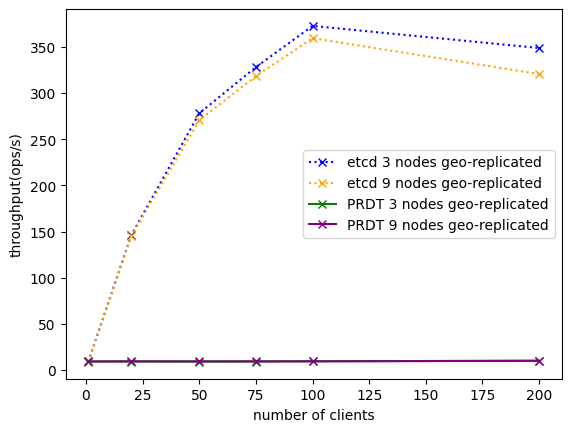

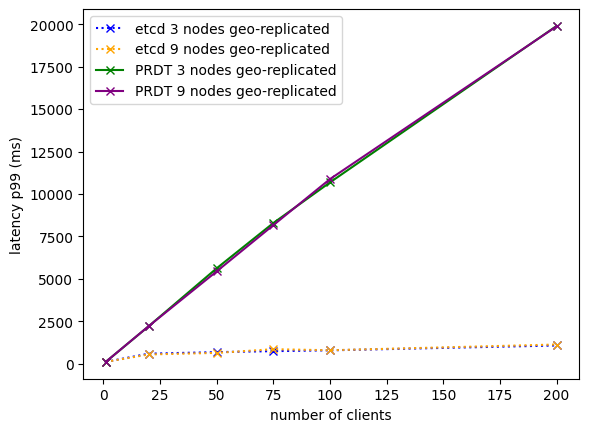

In [9]:
plot_dist_through()
plot_dist_lat()